In [2]:
import tensorflow as tf
print("Versión de TensorFlow:", tf.__version__)
print("Dispositivos GPU detectados:", tf.config.list_physical_devices('GPU'))

Versión de TensorFlow: 2.10.0
Dispositivos GPU detectados: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
def data_resampling(data, sfrq, start, stop):
    "sfreq = sampling_Frequency\
     start and stop is the range of the subject you want to downsample dataset\
     for example from 0 to 16 subjects loaded respectively is downsampled"
    for i in range(start,stop):
        data[i].resample(sfrq).to_data_frame()

In [37]:
def data_concat(data_before, data_after, start, stop):
    "input: (before arthmetic task dataframe, after_arthemetic task dataset, start, stop)\
    output : concated labelled data set for n number of subjects"
    frames = []
    
    for i in range(start, stop):
        d_b = data_before[i].to_data_frame()
        d_b['labels'] = 0
        d_a = data_after[i].to_data_frame()
        d_a['labels'] = 1
        frames.append(d_b)
        frames.append(d_a)
    model_input_data = pd.concat(frames)
    
    return model_input_data

In [ ]:
def create_dataset(data, data_after, start, stop, sfreq):
    "input:  data: before arthmetic task mne dataset\
             data_after: during arthmetic task mne dataset\
             start: starting point from where you want to take subjects\
             stop: till were you wanted to take subjects\
    for example: if you wish to take the subjects from the 0th subject to the 16th subject\
    output: train_dataset, test_dataset, X_con(array format of the dataset),y_con(array format of the label), dataframe format of the concated datset"
    
    
    dataframe = data_resampling(data, sfreq, start,stop)
    dataframe = data_concat(data, data_after, start,stop)
    dataframe.drop('time', axis = 1, inplace = True)
    X_con = dataframe.drop('labels', axis = 1)
    y_con = dataframe['labels']
    y_con = np.array(y_con)
    X_con = np.array(X_con)
    print(X_con.shape, y_con.shape)
    dataset = tf.data.Dataset.from_tensor_slices((X_con,y_con))
    dataset = dataset.shuffle(len(dataset))
    Datset_Size = X_con.shape[0]
    train_size = int(0.85*Datset_Size)
    test_size = int(0.15*Datset_Size)
    
    train_dataset = dataset.take(train_size)
    test_dataset = dataset.skip(train_size)
    #validation_dataset = remaining_dataset.take(validation_size)
    #test_dataset = remaining_dataset.skip(validation_size)

    train_dataset  = train_dataset.shuffle(len(train_dataset))
    train_dataset = train_dataset.batch(32)

    
    return train_dataset,test_dataset, X_con, y_con, dataframe

### Objective: To Classify Active state and Inactive state of the signal using raw EEG dataset

- Input: 21 features corresponding to 90k rows therefore final dataset size is 90k*21

- Output: labels 0, 1 active or inactive respectively

- 3 Models were tested in this experiment:

  1  LSTM model  |  2  Bidirectional LSTM  |  3  LSTM with attention

In [4]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.layers import Conv1D, LSTM , Dense, BatchNormalization, Input, Bidirectional, Dropout
from keras.models import Model
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

In [5]:
subjects= pd.read_csv('./eeg-during-mental-arithmetic-tasks/subject-info.csv')
subjects

,Subject,Age,Gender,Recording year,Number of subtractions,Count quality
0,Subject00,21,F,2011,9.70,0
1,Subject01,18,F,2011,29.35,1
2,Subject02,19,F,2012,12.88,1
3,Subject03,17,F,2010,31.00,1
4,Subject04,17,F,2010,8.60,0
5,Subject05,16,F,2010,20.71,1
6,Subject06,18,M,2011,4.35,0
7,Subject07,18,F,2012,13.38,1
8,Subject08,26,M,2011,18.24,1
9,Subject09,16,F,2010,7.00,0


### 1. Loading the Dataset
- Dataset is in MNE format
- 4 lists were created to store the dataset
- Sub_Raw_EEG and Sub_Raw_Data stores the ARRAY data of each subject and MNE FORMAT data for the 3 min data (non active)
- Sub_Raw_EEG_after and Sub_Raw_Data_After does the same as before for the 1 min data (mental active)

In [28]:
No_of_subjects = 16
def load_data(n):
    mne.set_log_level('WARNING')  # o 'ERROR' para ocultar casi todo
    sub_raw_eeg = []
    sub_raw_data =[]
    sub_raw_eeg_after= []
    sub_raw_data_after =[]
    for i in range(n):
        for j in range(2):
            if i<10:
                if j==0:
                    file = "./eeg-during-mental-arithmetic-tasks/"+ "Subject0"+ str(i)+"_"+ str(j+1) + ".edf"
                    data_after= mne.io.read_raw_edf(file)
                    raw_data_after = data_after.get_data()
                    sub_raw_data.append(data_after)
                    sub_raw_eeg.append(raw_data_after.T)
                else:
                    file = "./eeg-during-mental-arithmetic-tasks/"+ "Subject0"+ str(i)+"_"+ str(j+1) + ".edf"
                    data_after= mne.io.read_raw_edf(file)
                    raw_data_after = data_after.get_data()
                    sub_raw_data_after.append(data_after)
                    sub_raw_eeg_after.append(raw_data_after.T)
            else:
                if j==0:
                    file = "./eeg-during-mental-arithmetic-tasks/"+ "Subject"+ str(i)+"_"+ str(j+1) + ".edf"
                    data_after= mne.io.read_raw_edf(file)
                    raw_data_after = data_after.get_data()
                    sub_raw_data.append(data_after)
                    sub_raw_eeg.append(raw_data_after.T)
                else:
                    file = "./eeg-during-mental-arithmetic-tasks/"+ "Subject"+ str(i)+"_"+ str(j+1) + ".edf"
                    data_after= mne.io.read_raw_edf(file)
                    raw_data_after = data_after.get_data()
                    sub_raw_data_after.append(data_after)
                    sub_raw_eeg_after.append(raw_data_after.T)
    return     sub_raw_eeg, sub_raw_data, sub_raw_eeg_after, sub_raw_data_after


array_list,data,array_after,data_after = load_data(No_of_subjects)

In [35]:
data_resampling(data,200,0, 16) # Si la frecuencia de muestreo fue de 500 capturamos informacion de señales hasta 250 hz
                                # Para reducir carga computacional resampleamos a 200 hz que conserva informacion hasta 100 hz (de interes en EEG)
data[1].to_data_frame()         # 21 Canales de la señal EEG de un Sujeto

,time,EEG Fp1,EEG Fp2,EEG F3,EEG F4,EEG F7,EEG F8,EEG T3,EEG T4,EEG C3,...,EEG T6,EEG P3,EEG P4,EEG O1,EEG O2,EEG Fz,EEG Cz,EEG Pz,EEG A2-A1,ECG ECG
0,0.000,-7.521218,-7.902690,-5.157440,-3.056119,-7.199233,1.441334,-4.685986,-4.209371,-9.996631,...,-1.365096,-4.420563,-5.976177,-6.332193,-8.612370,-2.653707,-2.300166,-6.098055,-3.053953,-14.804146
1,0.005,-6.489272,-6.872284,-5.715363,-4.077606,-5.905425,-0.944437,-6.180097,-8.075448,-9.622474,...,-4.201454,-5.250287,-7.693947,-7.182419,-9.559812,-3.611509,-5.219589,-6.506519,-1.080254,-19.033082
2,0.010,-4.751956,-5.076590,-5.543748,-4.784178,-3.910932,-2.935082,-6.784168,-11.561892,-8.593325,...,-6.546015,-5.620971,-8.919708,-7.191688,-9.762861,-4.234008,-7.637029,-6.093582,1.027646,-30.921917
3,0.015,-2.957282,-3.264680,-4.370320,-4.672762,-1.866156,-3.843227,-3.968098,-12.487570,-6.056721,...,-6.400383,-4.310588,-8.242510,-4.163446,-7.929329,-4.797774,-7.609773,-3.603921,2.412389,-51.277959
4,0.020,-2.378895,-2.882112,-2.897415,-3.178410,-1.091243,-3.025480,1.619324,-9.732824,-2.515392,...,-3.170061,-1.223126,-5.175437,1.927905,-4.290590,-5.531690,-4.369583,-0.063251,1.938835,-56.755708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36395,181.975,0.003086,0.003314,0.001517,0.004333,0.001801,0.015492,0.002630,-0.002843,0.000844,...,0.003568,0.001575,-0.002768,0.006023,0.005149,-0.001483,-0.004407,0.005381,-0.002365,0.139809
36396,181.980,0.003562,0.002060,0.003096,0.001921,0.003233,0.001260,0.007156,0.006264,0.003047,...,0.001561,0.004124,0.001359,0.004533,0.003922,0.000898,0.002336,0.004916,-0.000416,0.011803
36397,181.985,-0.003998,-0.004736,-0.001576,-0.002826,-0.003046,-0.009337,-0.003439,-0.002508,-0.003943,...,-0.002626,-0.005300,-0.001981,-0.009467,-0.006787,-0.001288,-0.002105,-0.006902,0.002337,-0.149226
36398,181.990,0.008574,0.008463,0.004927,0.008123,0.006304,0.024225,0.009890,0.002669,0.006010,...,0.006852,0.008257,-0.000428,0.016298,0.013140,0.000098,-0.001617,0.013963,-0.004356,0.264206


## DATA PREPROCESSING
1) DATA RESAMPLLING:-  3 MIN DATA(WHICH IS OF BEFORE ARTHMETIC TASK) IS RESAMPLED INTO THE 1 MIN DATA, THEREFORE  90K ROWS CONVERTED INTO THE 30K
                       
2) DATA LABELLING: RESAMPLED DATA WHIHC IS OF BEFORE ARTHMETIC TASK IS RESAMPLED IS LABELLED 0 AND THE ARTH-MATIC TASK DATA OF 1MIN IS LABELLED 1

3) DATA CONCATATING: BOTH THE DATA OF THE BEFORE ARTHMETIC TASK DATA AND THE AFTER ARTHMETIC TASK DATA IS CONCATED TO FORM THE FINAL DATA THAT IS TO BE FED TO THE MODEL

4) TRAIN_TEST_VALIDATION SPLIT:- USED THE TENSORFLOW DATASET.API FUNCTION TO CREATE THE DATSET.
                                 THEN GIVEN THE SPLIT OF THE 70/15/15
           

In [38]:
train_dataset, test_dataset, X_con, y_con, dataframe = create_dataset(data, data_after, 0, 16, 200)

(1077200, 21) (1077200,)


In [39]:
dataframe

,EEG Fp1,EEG Fp2,EEG F3,EEG F4,EEG F7,EEG F8,EEG T3,EEG T4,EEG C3,EEG C4,...,EEG P3,EEG P4,EEG O1,EEG O2,EEG Fz,EEG Cz,EEG Pz,EEG A2-A1,ECG ECG,labels
0,-2.119744,-1.723607,-2.380444,0.706987,-2.764764,-0.223284,-3.483413,1.583404,-3.365195,1.494708,...,-3.798032,1.734423,-0.604699,4.696762,0.697927,-9.486074,-3.632927,2.115941,14.030502,0
1,-3.570063,-3.529288,-3.921574,-0.145306,-3.481501,-1.028055,-1.772794,4.302660,-1.996789,2.773407,...,0.807301,6.786074,4.003562,9.910219,-0.135669,-0.204113,2.485416,1.340512,6.146760,0
2,-5.306624,-5.335338,-6.367694,-1.524867,-3.956580,-1.562593,0.753763,7.803317,-0.621963,4.043281,...,6.506394,13.090400,10.108785,16.108114,-1.489544,11.173041,9.880418,0.386828,-6.066677,0
3,-6.829254,-6.126417,-9.842056,-3.499224,-4.126557,-0.705811,4.122489,11.532941,0.125590,4.685620,...,12.110745,19.515856,17.767216,22.640225,-3.422433,19.963278,16.673049,-0.235964,-25.786295,0
4,-6.928291,-5.240925,-11.859004,-4.727532,-4.529117,1.741049,6.442397,13.004970,-0.063597,4.096009,...,13.763724,21.664511,23.497660,26.897357,-4.650541,16.489138,18.064031,0.406990,-46.109694,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30995,0.000643,-0.001884,-0.000758,-0.000123,-0.001227,0.000123,0.001188,0.000178,0.001212,0.000931,...,0.000223,0.000310,0.000217,0.001252,0.001336,0.000527,0.000425,-0.000367,0.002146,1
30996,0.000643,-0.001884,-0.000758,-0.000123,-0.001227,0.000123,0.001188,0.000178,0.001212,0.000931,...,0.000223,0.000310,0.000217,0.001252,0.001336,0.000527,0.000425,-0.000367,0.002146,1
30997,0.000643,-0.001884,-0.000758,-0.000123,-0.001227,0.000123,0.001188,0.000178,0.001212,0.000931,...,0.000223,0.000310,0.000217,0.001252,0.001336,0.000527,0.000425,-0.000367,0.002146,1
30998,0.000643,-0.001884,-0.000758,-0.000123,-0.001227,0.000123,0.001188,0.000178,0.001212,0.000931,...,0.000223,0.000310,0.000217,0.001252,0.001336,0.000527,0.000425,-0.000367,0.002146,1


In [40]:
train_dataset_new= train_dataset.take(int(0.825*len(train_dataset)))
validation_dataset = train_dataset.skip(int(0.825*len(train_dataset)))

In [41]:
len(train_dataset_new), len(validation_dataset)

(23606, 5008)

In [42]:
shape = X_con.shape[1]
shape

21

In [43]:
train_dataset_new

<TakeDataset element_spec=(TensorSpec(shape=(None, 21), dtype=tf.float64, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

## LSTM MODEL 

1. input shape : (number of features, 1) #(21, 1) as there are 21 columns in our raw eeg dataset and 1 label correspond to it we want to predict

2. layers: 
        - 2 Dense layers
        - 3 LSTM layers
        - 1 dense output layer
        

In [44]:
shape = X_con.shape[1]
def create_model(shape):
    ip = Input(shape =(shape,1))
    Dense1 = Dense(64, activation = 'relu')(ip)
    Dense2 = Dense(128, activation = 'relu')(Dense1)
    lstm_1=  LSTM(256, return_sequences = True)(Dense2)
    drop = tf.keras.layers.Dropout(0.2)(lstm_1)
    lstm_3=  LSTM(256)(drop)
    drop2 = tf.keras.layers.Dropout(0.2)(lstm_3)
    Dense_3= Dense(128, activation = 'relu')(drop2)
    outputs = Dense(1, activation='sigmoid')(Dense_3)

    model = tf.keras.Model(ip, outputs)

    model.compile(optimizer='adam',
                  loss="binary_crossentropy", metrics=["acc"])
    
    return model

In [45]:
model_2 = create_model(shape)

In [46]:
model_2.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 21, 1)]           0         
                                                                 
 dense_4 (Dense)             (None, 21, 64)            128       
                                                                 
 dense_5 (Dense)             (None, 21, 128)           8320      
                                                                 
 lstm_2 (LSTM)               (None, 21, 256)           394240    
                                                                 
 dropout_2 (Dropout)         (None, 21, 256)           0         
                                                                 
 lstm_3 (LSTM)               (None, 256)               525312    
                                                                 
 dropout_3 (Dropout)         (None, 256)               0   

In [ ]:
model_2.fit(
    train_dataset_new,
    epochs=25,
    verbose=1
)

In [24]:
model_2.save_weights("lstm_model_mat_dataset.h5")

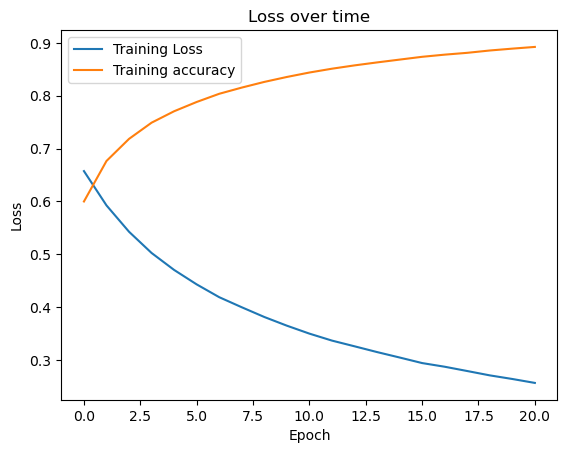

In [26]:
plt.plot(range(21), model_2.history.history['loss'], label="Training Loss")
plt.plot(range(21), model_2.history.history['acc'], label="Training accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over time")
plt.legend()